In [4]:
pip install hcipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.8/242.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 967.1/967.1 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.8/105.8 kB 9.6 MB/s eta 0:00:00


In [6]:
pip install tqdm


In [7]:
pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.6 MB/s eta 0:00:00


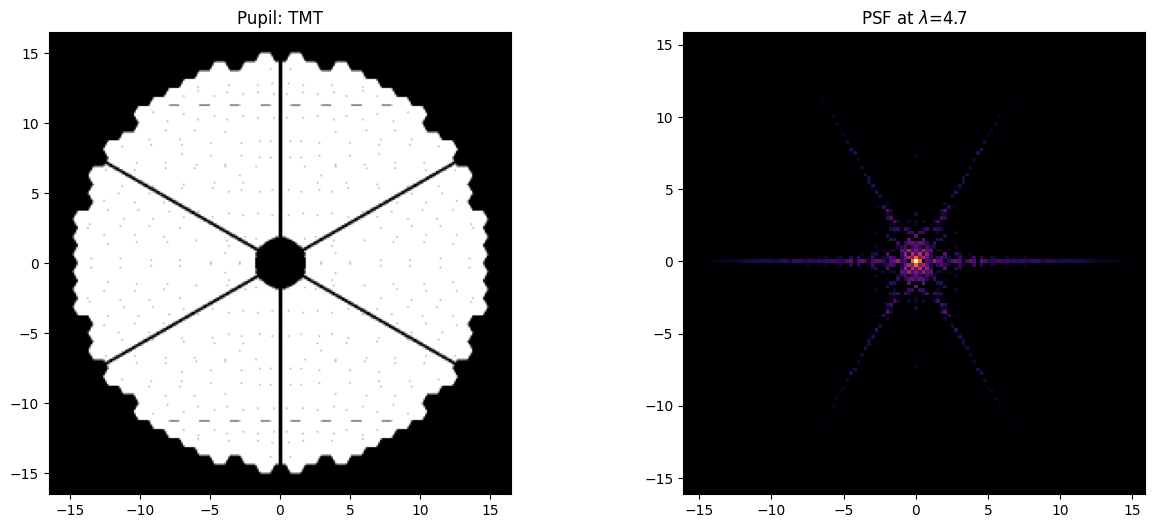

In [10]:
import hcipy
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files # Import files module for downloading

# 1. Setup Grids
focal_grid = hcipy.make_focal_grid(q=4, num_airy=16)

# 2. Define UI Widgets
telescope_type = widgets.Dropdown(
    options=['Simple Obstructed', 'Magellan', 'VLT', 'Subaru', 'Keck', 'LUVOIR-A', 'Luvoir-B', 'ELT', 'TMT', 'Hale', 'Habex', 'HST', 'JWST'],
    value='Simple Obstructed',
    description='Instrument:'
)

wavelength = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='λ')
log_stretch = widgets.IntSlider(value=-5, min=-8, max=-2, step=1, description='Log Contrast')
obscuration = widgets.FloatSlider(value=0.2, min=0, max=0.9, step=0.05, description='Obs Size')
num_spiders = widgets.IntSlider(value=4, min=0, max=8, step=1, description='Spider Legs')
spider_width = widgets.FloatSlider(value=0.02, min=0, max=0.1, step=0.01, description='Spider Width')

# 3. Add the Download Button
download_btn = widgets.Button(
    description='Download PNG',
    button_style='success', # Green color
    icon='download'
)

# 4. The Core Logic Function
def run_simulation():
    # Physical diameters
    tel_data = {
        'Simple Obstructed': 1.0, 'Magellan': 6.5, 'VLT': 8.2, 'Subaru': 8.2,
        'Keck': 10.95, 'LUVOIR-A': 15.0, 'Luvoir-B': 8.0, 'ELT': 39.3,
        'TMT': 30.0, 'Hale': 5.08, 'Habex': 4.0, 'HST': 2.4, 'JWST': 6.6
    }
    D_tel = tel_data.get(telescope_type.value, 1.0)

    pupil_grid = hcipy.make_pupil_grid(256, D_tel * 1.1)
    prop = hcipy.FraunhoferPropagator(pupil_grid, focal_grid)

    # Select Aperture
    if telescope_type.value == 'Simple Obstructed':
        ap_func = hcipy.make_obstructed_circular_aperture(D_tel, obscuration.value*D_tel, num_spiders.value, spider_width.value*D_tel)
    elif telescope_type.value == 'Magellan': ap_func = hcipy.make_magellan_aperture()
    elif telescope_type.value == 'VLT': ap_func = hcipy.make_vlt_aperture()
    elif telescope_type.value == 'Subaru': ap_func = hcipy.make_subaru_aperture()
    elif telescope_type.value == 'Keck': ap_func = hcipy.make_keck_aperture()
    elif telescope_type.value == 'LUVOIR-A': ap_func = hcipy.make_luvoir_a_aperture()
    elif telescope_type.value == 'Luvoir-B': ap_func = hcipy.make_luvoir_b_aperture()
    elif telescope_type.value == 'ELT': ap_func = hcipy.make_elt_aperture()
    elif telescope_type.value == 'TMT': ap_func = hcipy.make_tmt_aperture()
    elif telescope_type.value == 'Hale': ap_func = hcipy.make_hale_aperture()
    elif telescope_type.value == 'Habex': ap_func = hcipy.make_habex_aperture()
    elif telescope_type.value == 'HST': ap_func = hcipy.make_hst_aperture()
    elif telescope_type.value == 'JWST': ap_func = hcipy.make_jwst_aperture()

    pupil_field = hcipy.evaluate_supersampled(ap_func, pupil_grid, 2)
    wf = hcipy.Wavefront(pupil_field, wavelength.value)
    psf = prop.forward(wf).intensity
    psf /= psf.max()

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    hcipy.imshow_field(pupil_field, ax=ax[0], cmap='gray')
    hcipy.imshow_field(np.log10(psf + 1e-8), ax=ax[1], vmin=log_stretch.value, vmax=0, cmap='inferno')
    ax[0].set_title(f"Pupil: {telescope_type.value}")
    ax[1].set_title(f"PSF at r'$\lambda$'={wavelength.value}")

    return fig

# 5. UI Update Wrapper
def update_ui(*args):
    clear_output(wait=True)
    # Handle slider visibility
    is_simple = (telescope_type.value == 'Simple Obstructed')
    display_style = 'flex' if is_simple else 'none'
    for w in [obscuration, num_spiders, spider_width]:
        w.layout.display = display_style

    display(ui)
    run_simulation()
    plt.show()

# 6. Button Click Handler
def on_download_clicked(b):
    fig = run_simulation()
    # Format: {Instrument_name}_{Wavelength}.png
    filename = f"{telescope_type.value}_{wavelength.value}.png".replace(" ", "_")
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig) # Close the figure used for saving so it doesn't double-plot
    print(f"Successfully saved: {filename}")
    files.download(filename) # Add this line to download the file

# 7. Initialization
download_btn.on_click(on_download_clicked)
for w in [telescope_type, wavelength, obscuration, num_spiders, spider_width]:
    w.observe(update_ui, 'value')

ui = widgets.VBox([
    telescope_type, wavelength,
    obscuration, num_spiders, spider_width,
    download_btn
])

update_ui() # Initial launch